# 2 — Moellering & Tobler (1972) Figure 3

Reproduces the worked example from the original 1972 paper. A 16×16 raster of integer values `{2, 5, 8}` arranged as a checkerboard of checkerboards: a fine 2×2 alternation nested inside a coarse 2×2 quadrant pattern. The paper reports `TSS = 1152` and `TDF = 255`; the scale-variance decomposition concentrates equally at the **finest** and **coarsest** scales (50% / 50%), with zeros in between.

We run the example twice, end-to-end:

1. Through `scale_variance_raster` on the raster directly.
2. Through `scale_variance` on the same data flattened to a tabular    nested hierarchy.

Both paths return identical components — by design.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scalevar import scale_variance, scale_variance_raster

## Build the input — the 16×16 Figure 3 raster

Top-left 8×8 quadrant: a `{2, 5}` checkerboard. Top-right and bottom-left 8×8: `{5, 8}` checkerboards. Bottom-right 8×8: `{2, 5}` again. Two structural scales by construction: a 2-pixel alternation and an 8-pixel quadrant pattern.

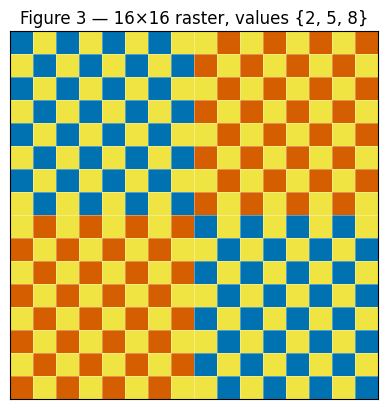

In [2]:
raster = np.array([
    [2, 5, 2, 5, 2, 5, 2, 5, 5, 8, 5, 8, 5, 8, 5, 8],
    [5, 2, 5, 2, 5, 2, 5, 2, 8, 5, 8, 5, 8, 5, 8, 5],
    [2, 5, 2, 5, 2, 5, 2, 5, 5, 8, 5, 8, 5, 8, 5, 8],
    [5, 2, 5, 2, 5, 2, 5, 2, 8, 5, 8, 5, 8, 5, 8, 5],
    [2, 5, 2, 5, 2, 5, 2, 5, 5, 8, 5, 8, 5, 8, 5, 8],
    [5, 2, 5, 2, 5, 2, 5, 2, 8, 5, 8, 5, 8, 5, 8, 5],
    [2, 5, 2, 5, 2, 5, 2, 5, 5, 8, 5, 8, 5, 8, 5, 8],
    [5, 2, 5, 2, 5, 2, 5, 2, 8, 5, 8, 5, 8, 5, 8, 5],
    [5, 8, 5, 8, 5, 8, 5, 8, 2, 5, 2, 5, 2, 5, 2, 5],
    [8, 5, 8, 5, 8, 5, 8, 5, 5, 2, 5, 2, 5, 2, 5, 2],
    [5, 8, 5, 8, 5, 8, 5, 8, 2, 5, 2, 5, 2, 5, 2, 5],
    [8, 5, 8, 5, 8, 5, 8, 5, 5, 2, 5, 2, 5, 2, 5, 2],
    [5, 8, 5, 8, 5, 8, 5, 8, 2, 5, 2, 5, 2, 5, 2, 5],
    [8, 5, 8, 5, 8, 5, 8, 5, 5, 2, 5, 2, 5, 2, 5, 2],
    [5, 8, 5, 8, 5, 8, 5, 8, 2, 5, 2, 5, 2, 5, 2, 5],
    [8, 5, 8, 5, 8, 5, 8, 5, 5, 2, 5, 2, 5, 2, 5, 2],
], dtype=float)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
palette = {2: '#0072B2', 5: '#F0E442', 8: '#D55E00'}
rgb = np.zeros(raster.shape + (3,))
for v, hexcol in palette.items():
    c = np.array([int(hexcol[i:i+2], 16) for i in (1, 3, 5)]) / 255.0
    rgb[raster == v] = c
ax.imshow(rgb, interpolation='nearest')
for k in range(17):
    ax.axhline(k - 0.5, color='white', lw=0.4, alpha=0.6)
    ax.axvline(k - 0.5, color='white', lw=0.4, alpha=0.6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Figure 3 — 16×16 raster, values {2, 5, 8}')
fig.tight_layout()
plt.show()

## Path 1 — `scale_variance_raster`

`num_levels=None` lets the package auto-pick `floor(log_2(16)) + 1 = 5` levels. The `{2, 5, 8}` cell counts are `64 / 128 / 64`, so the grand mean is exactly **5**, and `TSS = 64·9 + 128·0 + 64·9 = 1152` — the paper's number.

In [3]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # numpy array carries no CRS — expected
    raster_result = scale_variance_raster(raster, agg_fun='mean')

print(f'TSS        = {raster_result.total_ss}')
print(f'total_df   = {raster_result.total_df}')
print(f'grand_mean = {raster_result.grand_mean}')
raster_result.components.round(6)

TSS        = 1152.0
total_df   = 255
grand_mean = 5.0


,level,scale,sum_squares,df,mean_square,ss_share,ms_share,ss_cumulative
0,1,1.0,576.0,192,3.0,0.5,0.015385,0.5
1,2,2.0,0.0,48,0.0,0.0,0.000000,0.5
2,3,4.0,0.0,12,0.0,0.0,0.000000,0.5
3,4,8.0,576.0,3,192.0,0.5,0.984615,1.0
4,5,16.0,0.0,0,NaN,0.0,NaN,1.0


## Plot the scale-variance lollipop

Two equal peaks at the finest and coarsest scales, zeros in between — the structural fingerprint of two nested checkerboards.

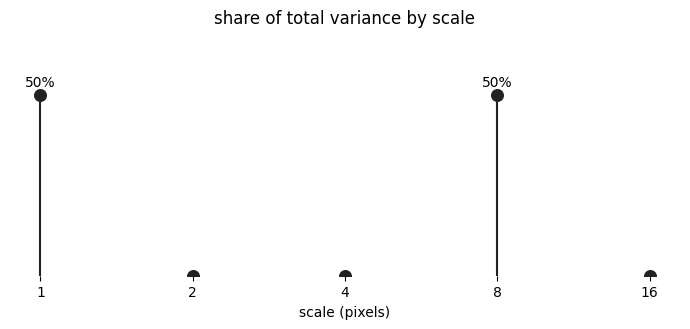

In [4]:
comp = raster_result.components
x = np.arange(len(comp))
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.vlines(x, 0, comp['ss_share'], color='#222', linewidth=1.5)
ax.scatter(x, comp['ss_share'], s=70, color='#222', zorder=3)
for xi, yi in zip(x, comp['ss_share'], strict=True):
    if yi > 0:
        ax.text(xi, yi + 0.025, f'{yi*100:.0f}%', ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(s)}" for s in comp['scale']])
ax.set_xlabel('scale (pixels)')
ax.set_yticks([])
ax.set_ylim(0, max(comp['ss_share']) * 1.35)
ax.axhline(0, color='#999', linewidth=0.6)
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_title('share of total variance by scale')
fig.tight_layout()
plt.show()

## Path 2 — `scale_variance` on the same data, flattened

Build a 256-row dataframe with one row per cell. `id_level1` is the cell's row-major index; the parent IDs follow the 2× nested blocking structure (`id_level{n+1}` groups together `2 × 2` siblings of `id_level{n}`, on the level-`n` grid).

In [5]:
rows, cols = raster.shape
rr, cc = np.mgrid[0:rows, 0:cols]
tab = pd.DataFrame({
    'value':     raster.ravel(),
    'id_level1': (rr * cols + cc).ravel() + 1,
    'id_level2': ((rr // 2) * (cols // 2)  + (cc // 2)).ravel() + 1,
    'id_level3': ((rr // 4) * (cols // 4)  + (cc // 4)).ravel() + 1,
    'id_level4': ((rr // 8) * (cols // 8)  + (cc // 8)).ravel() + 1,
    'id_level5': np.ones(rows * cols, dtype=int),
})
tab.head()

,value,id_level1,id_level2,id_level3,id_level4,id_level5
0,2.0,1,1,1,1,1
1,5.0,2,1,1,1,1
2,2.0,3,2,1,1,1
3,5.0,4,2,1,1,1
4,2.0,5,3,2,1,1


In [6]:
tab_result = scale_variance(
    tab,
    value='value',
    id_cols=['id_level1', 'id_level2', 'id_level3', 'id_level4', 'id_level5'],
    agg_fun='mean',
)
print(f'TSS        = {tab_result.total_ss}')
print(f'total_df   = {tab_result.total_df}')
print(f'grand_mean = {tab_result.grand_mean}')
tab_result.components.round(6)

TSS        = 1152.0
total_df   = 255
grand_mean = 5.0


,level,scale,sum_squares,df,mean_square,ss_share,ms_share,ss_cumulative
0,1,NaN,576.0,192,3.0,0.5,0.015385,0.5
1,2,NaN,0.0,48,0.0,0.0,0.000000,0.5
2,3,NaN,0.0,12,0.0,0.0,0.000000,0.5
3,4,NaN,576.0,3,192.0,0.5,0.984615,1.0
4,5,NaN,0.0,0,NaN,0.0,NaN,1.0


## Both paths agree on every component

The tabular core has no notion of pixel size, so its `scale` column is `NaN` (only the raster path knows the cell size). All other columns — `sum_squares`, `df`, `mean_square`, `ss_share`, `ms_share`, `ss_cumulative` — match exactly.

In [7]:
shared_cols = ['level', 'sum_squares', 'df', 'mean_square',
               'ss_share', 'ms_share', 'ss_cumulative']
pd.testing.assert_frame_equal(
    raster_result.components[shared_cols].reset_index(drop=True),
    tab_result.components[shared_cols].reset_index(drop=True),
)
'raster path == tabular path'

'raster path == tabular path'

## Sanity checks against the paper

Both paths must close the decomposition identity exactly, and must reproduce Moellering & Tobler's published totals.

In [8]:
for label, res in [('raster', raster_result), ('tabular', tab_result)]:
    assert res.total_ss == 1152.0,           f'{label}: TSS != 1152'
    assert res.total_df == 255,              f'{label}: TDF != 255'
    assert res.grand_mean == 5.0,            f'{label}: grand_mean != 5'
    assert abs(res.components['sum_squares'].sum() - res.total_ss) < 1e-9
    assert res.components['df'].sum() == res.total_df
    assert abs(res.components['ss_share'].sum() - 1.0) < 1e-12
'all checks pass — matches the 1972 paper'

'all checks pass — matches the 1972 paper'